In [10]:
import mido
from mido import MidiFile
import torchaudio

import os

In [11]:
def midi_to_frequency(note_number):
    return 440.0 * (2 ** ((note_number - 69) / 12))

#track_path = 'datasets/slakh2100_flac_redux/train/Track00001/'

midi_file = MidiFile('datasets/slakh2100_flac_redux/train/Track00001/MIDI/S00.mid')
audio_file = 'datasets/slakh2100_flac_redux/train/Track00001/stems/S00.flac'

In [17]:
for track in midi_file.tracks:
    print(f"Traccia: {track.name}")
    for msg in track:
        print(msg)
        if msg.type == 'note_on' and msg.velocity > 0:  # Controlla se è una nota attivata
            note = msg.note  # Numero della nota MIDI
            frequency = midi_to_frequency(note)  # Calcola la frequenza
            print(f"Nota MIDI: {note}, Frequenza: {frequency:.2f} Hz, Velocità: {msg.velocity}")

Traccia: 
MetaMessage('set_tempo', tempo=749906, time=0)
MetaMessage('time_signature', numerator=4, denominator=4, clocks_per_click=24, notated_32nd_notes_per_beat=8, time=0)
MetaMessage('key_signature', key='C', time=0)
MetaMessage('lyrics', text='Eu ', time=3209)
MetaMessage('lyrics', text='não ', time=27)
MetaMessage('lyrics', text='sei ', time=35)
MetaMessage('lyrics', text='prá ', time=59)
MetaMessage('lyrics', text='on ', time=35)
MetaMessage('lyrics', text='de ', time=54)
MetaMessage('lyrics', text='vou ', time=37)
MetaMessage('lyrics', text='po ', time=511)
MetaMessage('lyrics', text='dea ', time=27)
MetaMessage('lyrics', text='té ', time=33)
MetaMessage('lyrics', text='não ', time=65)
MetaMessage('lyrics', text='dar ', time=32)
MetaMessage('lyrics', text='em ', time=66)
MetaMessage('lyrics', text='na ', time=38)
MetaMessage('lyrics', text='da ', time=51)
MetaMessage('lyrics', text='a... ', time=33)
MetaMessage('lyrics', text='mi ', time=423)
MetaMessage('lyrics', text='nha ', 

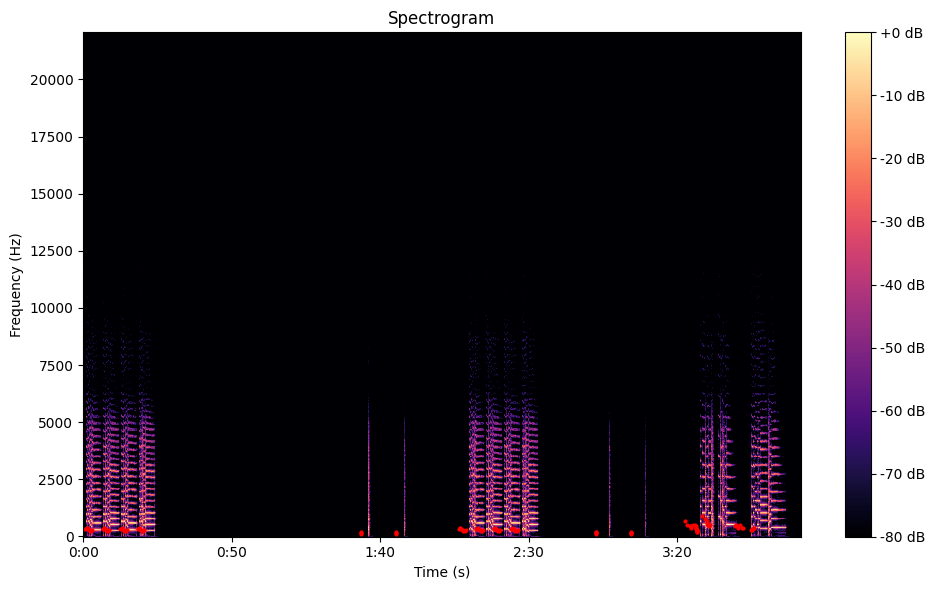

In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load the audio file
y, sr = librosa.load(audio_file, sr=None)  # Load audio with its original sample rate

# Compute the spectrogram
S = librosa.stft(y)  # Short-time Fourier Transform
S_db = librosa.amplitude_to_db(abs(S), ref=np.max)  # Convert amplitude to decibels

tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

# Plot the spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')

for track in midi_file.tracks:
    cumulative_time = 0  # Tempo cumulativo in ticks
    for msg in track:
        cumulative_time += msg.time  # Aggiungi il delta time al tempo cumulativo
        if msg.type == 'note_on' and msg.velocity > 0:  # Controlla se è una nota attivata
            note = msg.note  # Numero della nota MIDI
            frequency = midi_to_frequency(note)  # Calcola la frequenza
            note_on_time = mido.tick2second(cumulative_time, midi_file.ticks_per_beat, mido.bpm2tempo(tempo[0]))  # Converti i ticks in secondi
            
            # Plot a point on the spectrogram corresponding to the note
            plt.plot(note_on_time, frequency, 'ro', markersize=2)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

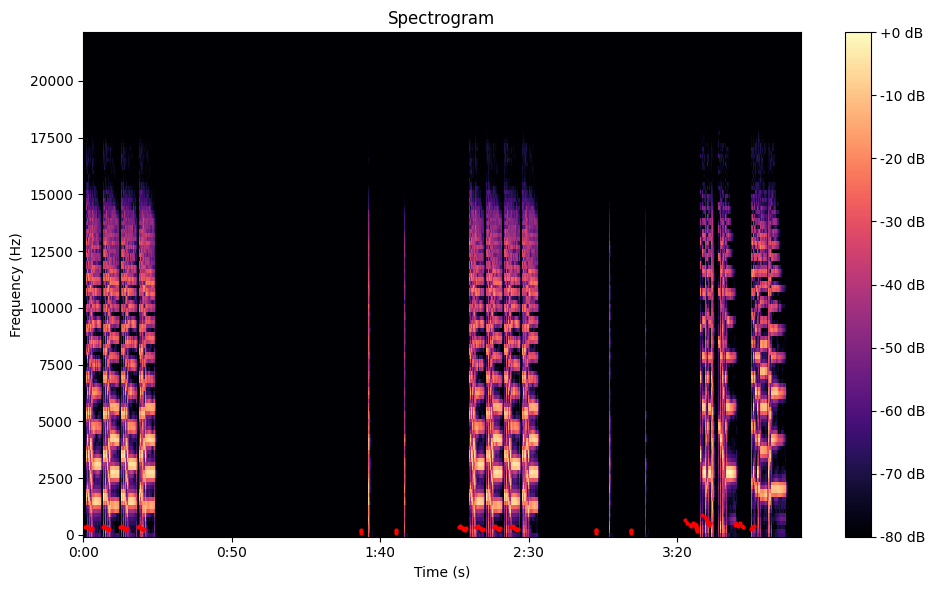

In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load the audio file
y, sr = librosa.load(audio_file, sr=None)  # Load audio with its original sample rate

# Compute the spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S, ref=np.max)  # Convert amplitude to decibels

tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

# Plot the spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')

for track in midi_file.tracks:
    cumulative_time = 0  # Tempo cumulativo in ticks
    for msg in track:
        cumulative_time += msg.time  # Aggiungi il delta time al tempo cumulativo
        if msg.type == 'note_on' and msg.velocity > 0:  # Controlla se è una nota attivata
            note = msg.note  # Numero della nota MIDI
            frequency = midi_to_frequency(note)  # Calcola la frequenza
            note_on_time = mido.tick2second(cumulative_time, midi_file.ticks_per_beat, mido.bpm2tempo(tempo[0]))  # Converti i ticks in secondi
            
            # Plot a point on the spectrogram corresponding to the note
            plt.plot(note_on_time, frequency, 'ro', markersize=2)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

In [18]:
from transformers import ASTFeatureExtractor

y, sr = librosa.load(audio_file, sr=16000)

feature_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.448-v2")

feature_extractor.max_length = 4*60*100
feature_extractor.num_mel_bins = 128

features = feature_extractor(
            y, 
            return_tensors="pt", 
            sampling_rate=sr
        )["input_values"]


features= librosa.power_to_db(features.squeeze(0).transpose(1,0).numpy(), ref=np.max)

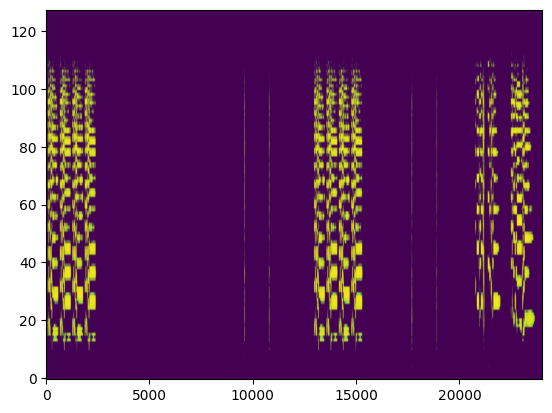

In [19]:
plt.imshow(features, aspect='auto', origin='lower')